# Food-101 Dataset Analysis

This notebook downloads and inspects Food-101 for the knowledge distillation experiments. It summarizes split sizes, classes, balance, image statistics, and visual examples.

## Setup

Run this notebook from the project root. If dependencies are missing, install the project first with:

```bash
.venv/bin/pip install -e .
```

In [2]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torchvision import datasets, transforms

DATA_ROOT = Path("../data") if Path.cwd().name == "notebooks" else Path("data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
torch.manual_seed(42)

DATA_ROOT.resolve()

PosixPath('/home/zeneto/projects/mo434-dl-knowledge-distillation/data')

## Download and Load Splits

In [3]:
display_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_full = datasets.Food101(root=str(DATA_ROOT), split="train", transform=display_transform, download=True)
test_ds = datasets.Food101(root=str(DATA_ROOT), split="test", transform=display_transform, download=True)

# Match the project loader: reserve every 10th train image as validation.
val_indices = list(range(0, len(train_full), 10))
train_indices = [idx for idx in range(len(train_full)) if idx % 10 != 0]
train_ds = torch.utils.data.Subset(train_full, train_indices)
val_ds = torch.utils.data.Subset(train_full, val_indices)

splits = {"train": train_ds, "val": val_ds, "test": test_ds}
pd.DataFrame([
    {"split": name, "images": len(ds), "classes": len(train_full.classes)} for name, ds in splits.items()
])

,split,images,classes
0,train,68175,101
1,val,7575,101
2,test,25250,101


## Classes

In [4]:
classes = list(train_full.classes)
print(f"Number of food categories: {len(classes)}")
classes[:30]

Number of food categories: 101


['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes']

## Class Balance

In [5]:
def labels_from_dataset(ds):
    """
    Return labels without loading images.

    Works for:
    - torchvision.datasets.Food101
    - torch.utils.data.Subset(Food101)
    - ImageFolder-like datasets with .targets
    """
    if isinstance(ds, torch.utils.data.Subset):
        base = ds.dataset
        indices = np.asarray(ds.indices)

        if hasattr(base, "_labels"):      # torchvision.datasets.Food101
            labels = np.asarray(base._labels)
            return labels[indices].tolist()

        if hasattr(base, "targets"):      # ImageFolder-style datasets
            labels = np.asarray(base.targets)
            return labels[indices].tolist()

        raise ValueError("Subset base dataset has no known label metadata.")

    if hasattr(ds, "_labels"):            # torchvision.datasets.Food101
        return list(ds._labels)

    if hasattr(ds, "targets"):            # ImageFolder-style datasets
        return list(ds.targets)

    raise ValueError("Dataset has no known label metadata. Avoid iterating ds[i].")


def label_counts(ds, classes):
    labels = labels_from_dataset(ds)
    counts = Counter(labels)

    return pd.DataFrame(
        [
            {
                "class_id": idx,
                "class_name": classes[idx],
                "count": counts.get(idx, 0),
            }
            for idx in range(len(classes))
        ]
    ).sort_values("count", ascending=False)


train_counts = label_counts(train_ds, classes)
val_counts = label_counts(val_ds, classes)
test_counts = label_counts(test_ds, classes)

balance_summary = pd.DataFrame([
    {
        "split": "train",
        "min": train_counts["count"].min(),
        "median": train_counts["count"].median(),
        "max": train_counts["count"].max(),
    },
    {
        "split": "val",
        "min": val_counts["count"].min(),
        "median": val_counts["count"].median(),
        "max": val_counts["count"].max(),
    },
    {
        "split": "test",
        "min": test_counts["count"].min(),
        "median": test_counts["count"].median(),
        "max": test_counts["count"].max(),
    },
])

balance_summary

,split,min,median,max
0,train,675,675.0,675
1,val,75,75.0,75
2,test,250,250.0,250


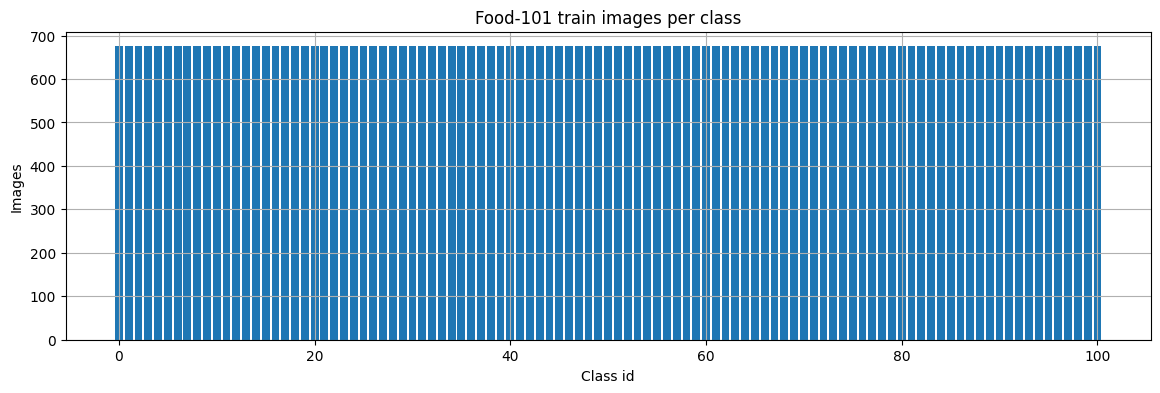

,class_id,class_name,count
0,0,apple_pie,675
1,1,baby_back_ribs,675
2,2,baklava,675
3,3,beef_carpaccio,675
4,4,beef_tartare,675
5,5,beet_salad,675
6,6,beignets,675
7,7,bibimbap,675
8,8,bread_pudding,675
9,9,breakfast_burrito,675


In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(np.arange(len(train_counts)), train_counts.sort_values("class_id")["count"])
ax.set_title("Food-101 train images per class")
ax.set_xlabel("Class id")
ax.set_ylabel("Images")
plt.show()

train_counts.head(10)

## Image Shape and Pixel Statistics

In [7]:
sample_size = min(512, len(train_ds))
indices = torch.randperm(len(train_ds))[:sample_size].tolist()
pixels = []
shapes = []

for subset_idx in indices:
    image, _ = train_ds[subset_idx]
    shapes.append(tuple(image.shape))
    pixels.append(image.reshape(3, -1))

pixel_tensor = torch.cat(pixels, dim=1)
pd.DataFrame({
    "channel": ["red", "green", "blue"],
    "mean": pixel_tensor.mean(dim=1).numpy(),
    "std": pixel_tensor.std(dim=1).numpy(),
}), Counter(shapes).most_common(5)

(  channel      mean       std
 0     red  0.542163  0.266936
 1   green  0.441124  0.269514
 2    blue  0.339224  0.276344,
 [((3, 224, 224), 512)])

## Example Images

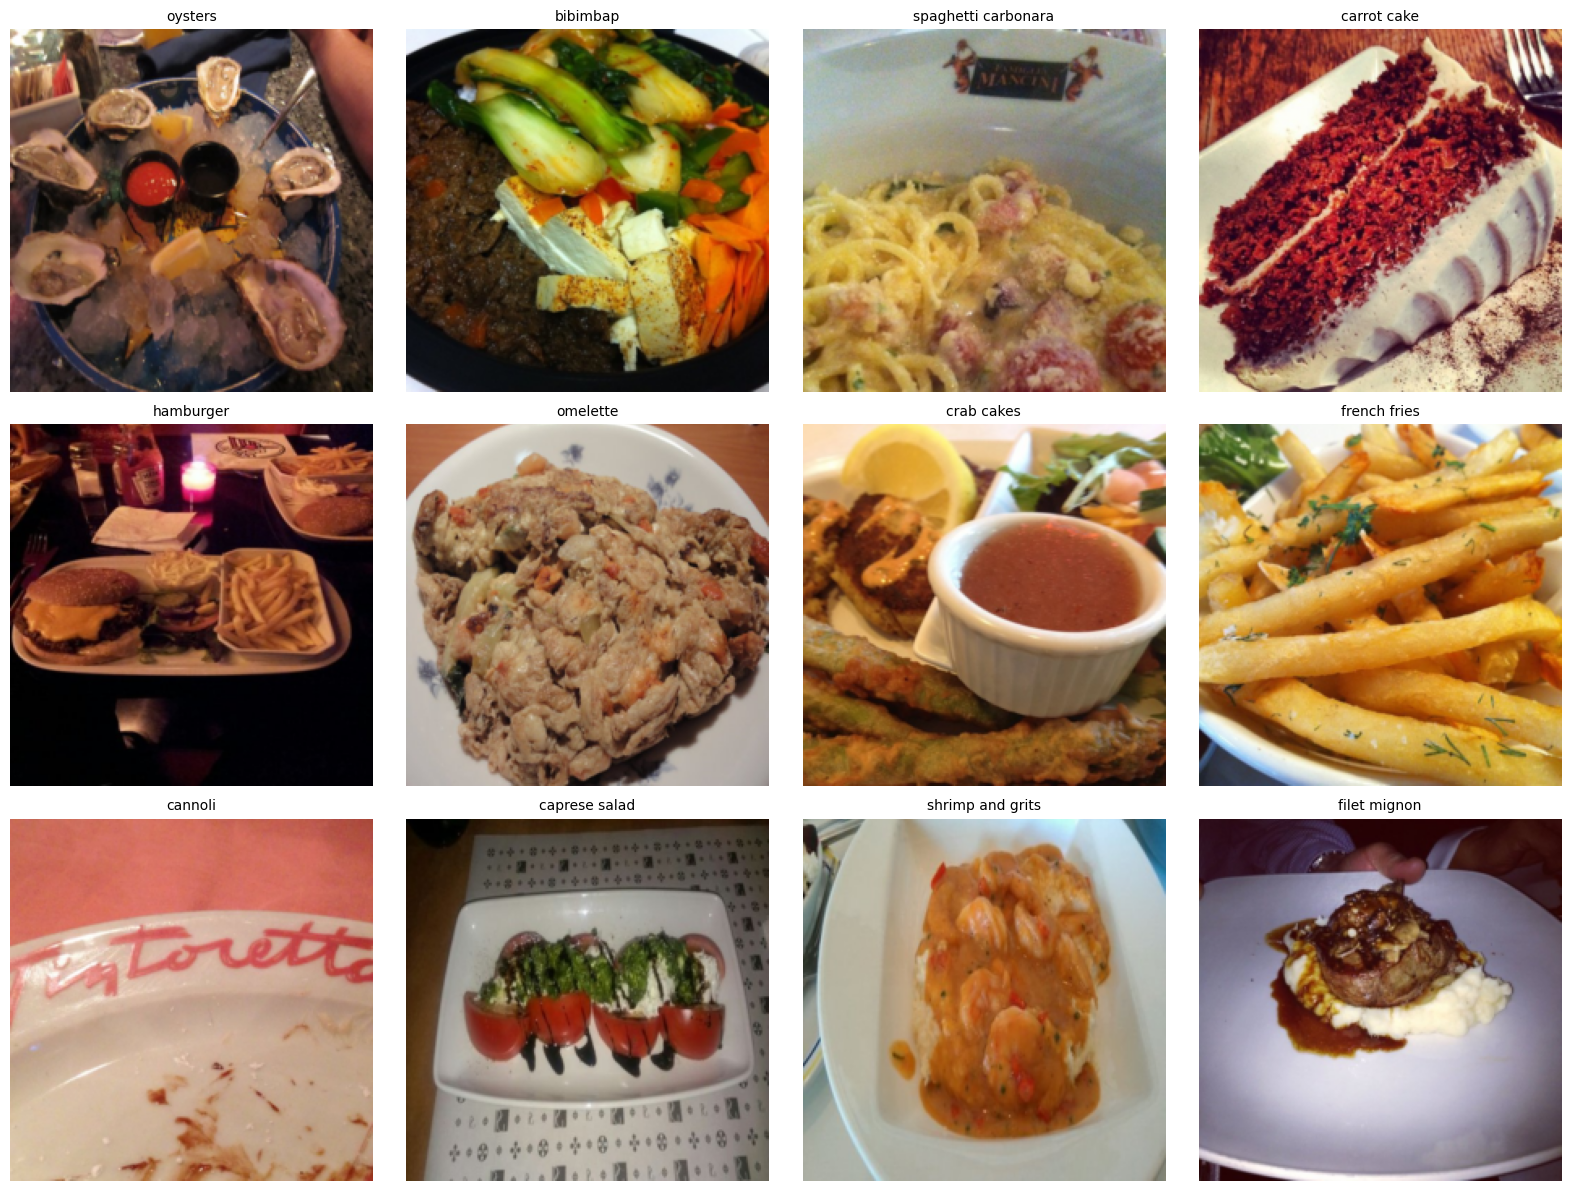

In [8]:
def show_examples(ds, classes, n=12):
    indices = torch.randperm(len(ds))[:n].tolist()
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, indices):
        image, label = ds[idx]
        ax.imshow(image.permute(1, 2, 0).numpy())
        ax.set_title(classes[label].replace("_", " "), fontsize=10)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()

show_examples(train_ds, classes, n=12)

## Notes for the Distillation Project

- Food-101 is visually diverse: categories vary by texture, viewpoint, background, and serving style.
- Top-5 accuracy is useful because some classes are semantically and visually close.
- Post-GAP distillation may be competitive because the dataset emphasizes global appearance and texture cues, while pre-GAP distillation can still help preserve localized food regions.